In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from imblearn.over_sampling import SMOTE
import numpy as np
from numpy.random import uniform
import matplotlib.pyplot as plt

import helper

In [2]:
df = helper.prepare_data()
X = df.drop(columns=['default.payment.next.month']).values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled,y = SMOTE(random_state=42).fit_resample(X_scaled,y)

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, 'PCA of Credit Card Default Dataset')

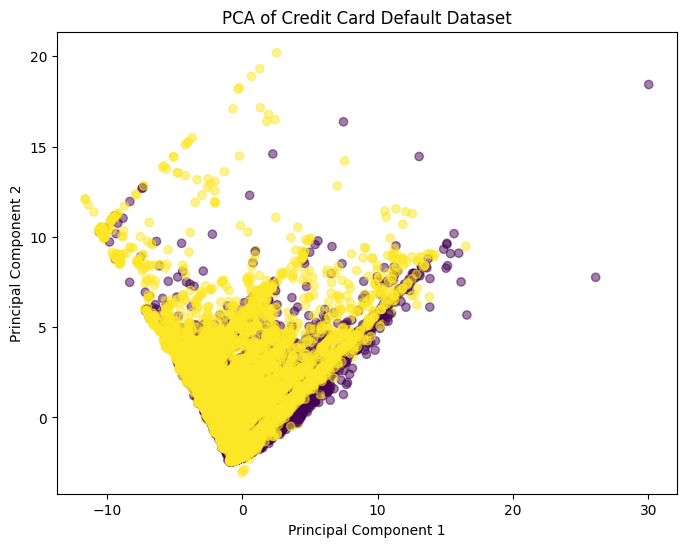

In [4]:
# scatter plot of the PCA-transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Credit Card Default Dataset')

In [5]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_pca)
y_pred = kmeans.predict(X_pca)

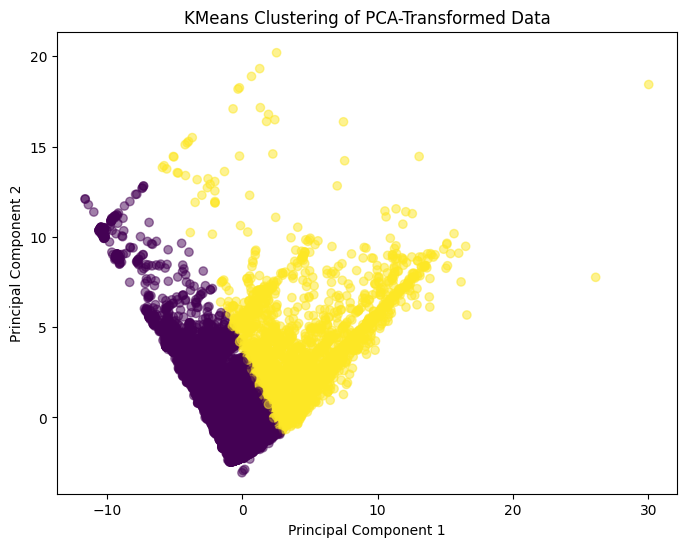

In [6]:
# scatter plot of the results
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KMeans Clustering of PCA-Transformed Data')
plt.show()

In [7]:
def showplot(centroids):
  plt.figure(figsize=(9, 3.5))
  plt.plot(X_pca[:,0], X_pca[:,1], "k*", label="Unlabel instance")
  plt.plot([x for x, _ in centroids],[y for _, y in centroids], '+', markersize=10,)
  plt.xlabel("Petal length", fontsize=10)
  plt.ylabel("Petal width", fontsize=10)
  plt.legend(fontsize=10)
  plt.show()

In [8]:
def euclidean(point, centroid):
  return np.sqrt(np.sum((point - centroid) ** 2))
n_clusters = 2 # The data set have 3 class hench 3 cluster centroids we need to make

minpoint, maxpoint = np.min(X_pca[:,:], axis=0), np.max(X_pca[:,:], axis=0)
centroids = np.array([uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)])
print(minpoint, maxpoint)
print(centroids)

[-11.61984855  -3.06065383] [30.03251461 20.19888053]
[[24.56801635 10.3136309 ]
 [28.82903119 18.10689292]]


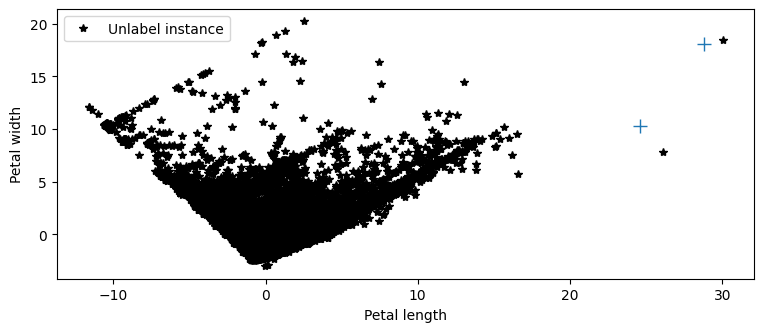

In [9]:
showplot(centroids)

In [10]:
def showplotwithclass(sorted_x, centroids):
    plt.figure(figsize=(9, 3.5))

    colors = plt.cm.tab20.colors

    for i, cluster_points in enumerate(sorted_x):
        if len(cluster_points) == 0:  # Skip empty clusters
            continue
        cluster_points = np.array(cluster_points)
        plt.plot(cluster_points[:, 0], cluster_points[:, 1],
                 marker='o', linestyle='', color=colors[i % len(colors)],
                 label=f"Class {i + 1} instances")

    plt.plot([x for x, _ in centroids],
             [y for _, y in centroids],
             'k+', markersize=10, label="Centroids")

    plt.xlabel("Petal length", fontsize=10)
    plt.ylabel("Petal width", fontsize=10)
    plt.legend(fontsize=10)
    plt.show()
def calculateClass(X, centroids, showplot=False):
  sorted_x = [[] for _ in range(n_clusters)]  # Independent lists
  for x in X:
    dists = [euclidean(x, centroid) for centroid in centroids]
    centroid_idx = np.argmin(dists)
    sorted_x[centroid_idx].append(x)

  sorted_x = [np.array(cluster) for cluster in sorted_x]

  if showplot:
    showplotwithclass(sorted_x, centroids)
  return sorted_x

In [11]:
def adjustCentroid(sorted_x, centroids, showplot=False):
  prev_centroids = centroids
  centroids = [np.mean(cluster, axis=0) for cluster in sorted_x]
  for i, centroid in enumerate(centroids):
    if np.isnan(centroid).any():  # Catch any np.nans, resulting from a centroid having no points
      centroids[i] = prev_centroids[i]

  if showplot:
    showplotwithclass(sorted_x, centroids)
  return centroids
def train(X, n_clusters):
  minpoint, maxpoint = np.min(X[:,:], axis=0), np.max(X[:,:], axis=0)
  centroids = np.array([uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)])
  while True:
    sorted_x = calculateClass(X, centroids)
    new_centroid = adjustCentroid(sorted_x, centroids)
    if np.allclose(centroids, new_centroid): return centroids
    centroids = new_centroid

In [12]:
centroids = train(X_pca, n_clusters)

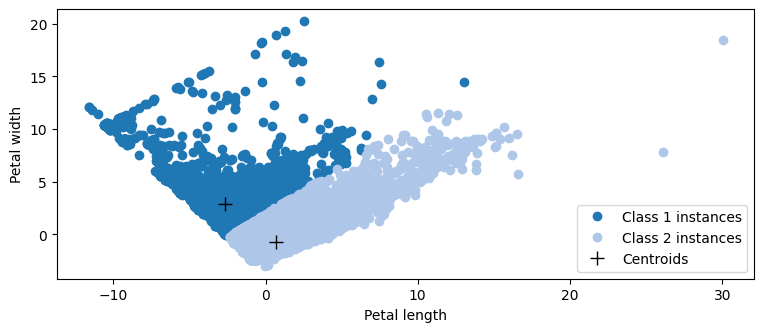

In [13]:
res = calculateClass(X_pca, centroids, showplot=True)

In [20]:
X_agg = X[:1000]
y_agg = y[:1000]
aag_scaler = StandardScaler()
X_agg_scaled = aag_scaler.fit_transform(X_agg)
X_agg_scaled,y_agg = SMOTE(random_state=42).fit_resample(X_agg_scaled,y_agg)

In [21]:
agg_pca = PCA(n_components=2)
X_agg_pca = agg_pca.fit_transform(X_agg_scaled)

Text(0.5, 1.0, 'PCA of Credit Card Default Dataset')

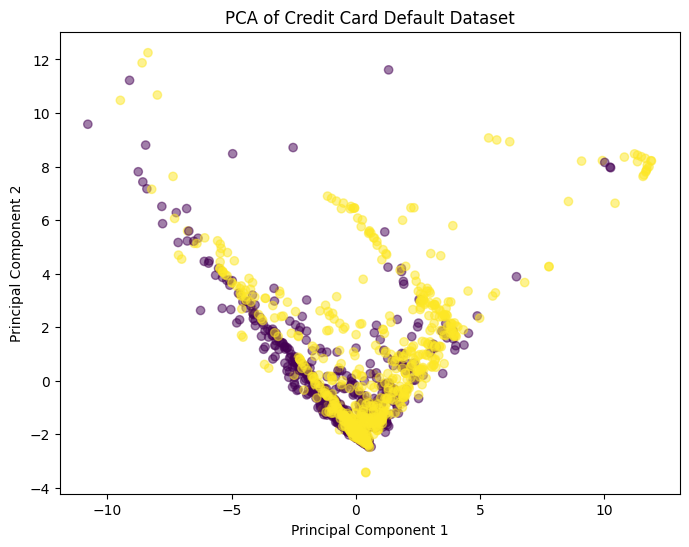

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(X_agg_pca[:,0], X_agg_pca[:,1], c=y_agg, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Credit Card Default Dataset')

In [23]:
y_pred = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward').fit_predict(X_agg_pca)

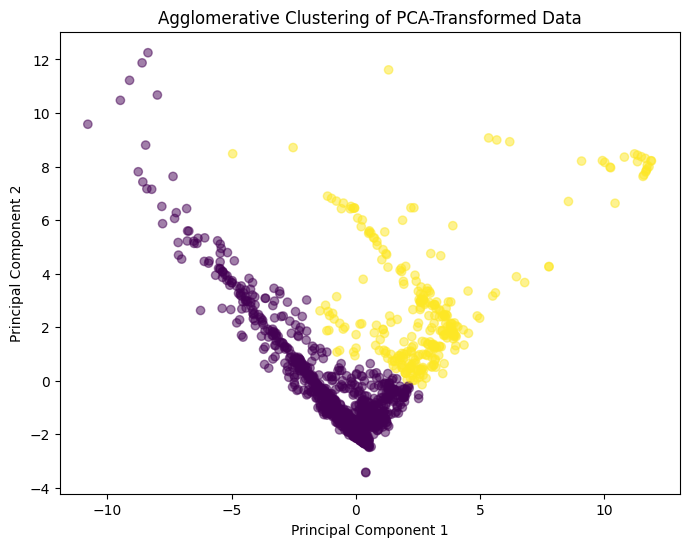

In [24]:
# plot the results
plt.figure(figsize=(8,6))
plt.scatter(X_agg_pca[:,0], X_agg_pca[:,1], c=y_pred, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering of PCA-Transformed Data')
plt.show()

In [25]:
class AgglomerativeClusteringScratch:
  def __init__(self, n_clusters=None, linkage='average'):
    # Use euclidean matric for computing pairwise distance matrix
    self.n_clusters = n_clusters

    if linkage == 'complete':
      self.linkage_distance_func = self.max_linkage_distance
    elif linkage == 'single':
      self.linkage_distance_func = self.min_linkage_distance
    elif linkage == 'average':
      self.linkage_distance_func = self.avg_linkage_distance
    elif linkage == 'ward':
      self.linkage_distance_func = self.ward_method_distance

  def avg_linkage_distance(self, cluster_A, cluster_B):
    # Compute average linkage distance between two clusters
    distance = 0
    for i in range(cluster_A.shape[0]):
      distance += np.linalg.norm(cluster_B - cluster_A[i, :], axis=1).sum()
    distance /= (cluster_A.shape[0] * cluster_B.shape[0])
    return distance

  def max_linkage_distance(self, cluster_A, cluster_B):
    # Compute maximum linkage distance between two clusters
    distance = 0
    for i in range(cluster_A.shape[0]):
      distance = np.append(np.linalg.norm(cluster_B - cluster_A[i, :], axis=1), distance).max()
    return distance

  def min_linkage_distance(self, cluster_A, cluster_B):
    # Compute minimum linkage distance between two clusters
    distance = np.inf
    for i in range(cluster_A.shape[0]):
      distance = np.append(np.linalg.norm(cluster_B - cluster_A[i, :], axis=1), distance).min()
    return distance

  def ward_method_distance(self, cluster_A, cluster_B):
    # Compute the Ward linkage distance between two clusters
    n_A = cluster_A.shape[0]
    n_B = cluster_B.shape[0]

    centroid_A = np.mean(cluster_A, axis=0)
    centroid_B = np.mean(cluster_B, axis=0)

    # Distance is proportional to the squared Euclidean distance between centroids
    # scaled by size of the clusters
    diff = centroid_A - centroid_B
    distance = (n_A * n_B) / (n_A + n_B) * np.dot(diff, diff)

    return distance

  def pairwise_distance(self, data, n_samples):
    # Compute the pairwise distance matrix in euclidean matric
    distance_mat = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(i + 1, n_samples):
        distance = np.linalg.norm(data[i] - data[j])
        distance_mat[i, j] = distance
        distance_mat[j, i] = distance
    return distance_mat

  def update(self, data, distance_mat, labels):
      #"Find closest clusters, merge clusters, delete cluster, update distance"
      idx_upper = np.triu_indices(distance_mat.shape[0], k=1)  # Index of upper part of distance matrix (skip diagonal)
      min_value = np.min(distance_mat[idx_upper])  # Value of idx_upper
      row, col = np.argwhere(distance_mat == min_value)[0]  # Index of min_value (same as d_kl)

      # Update label
      labels[labels == col] = row
      labels[labels > col] -= 1

      # Deleted the row and column 'col'
      distance_mat = np.delete(distance_mat, col, 0)
      distance_mat = np.delete(distance_mat, col, 1)

      # Update distance matrix
      for i in range(len(distance_mat)):
          distance_mat[row, i] = self.linkage_distance_func(data[labels == row], data[labels == i])
          distance_mat[i, row] = distance_mat[row, i]
      return distance_mat, labels

  def fit_predict(self, X):
    self.data = X
    self.n_samples = self.data.shape[0]
    self.initial_distance = self.pairwise_distance(self.data, self.n_samples)
    self.labels = np.arange(self.n_samples)
    self.distance_matrix = self.initial_distance.copy()
    while len(np.unique(self.labels)) > self.n_clusters:
      # Fill in the diagonal as infinity to determine that the distance is the same position.
      np.fill_diagonal(self.distance_matrix, np.inf)
      self.distance_matrix, self.labels = self.update(self.data, self.distance_matrix, self.labels)

    return self.labels

In [26]:
X_agg_100 = X[:100]
y_agg_100 = y[:100]
aag_scaler = StandardScaler()
X_agg_100 = aag_scaler.fit_transform(X_agg_100)
X_agg_100,y_agg_100 = SMOTE(random_state=42).fit_resample(X_agg_100,y_agg_100)
pca = PCA(n_components=2)
X_agg_100_pca = pca.fit_transform(X_agg_100)

Text(0.5, 1.0, 'PCA of Credit Card Default Dataset')

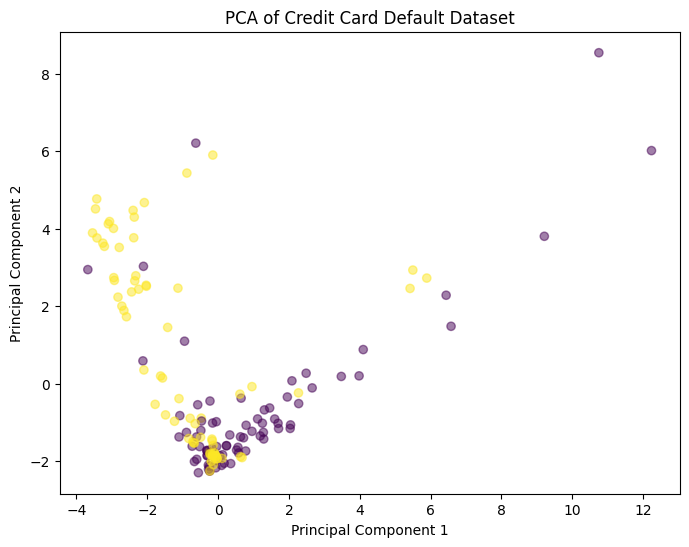

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(X_agg_100_pca[:,0], X_agg_100_pca[:,1], c=y_agg_100, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Credit Card Default Dataset')

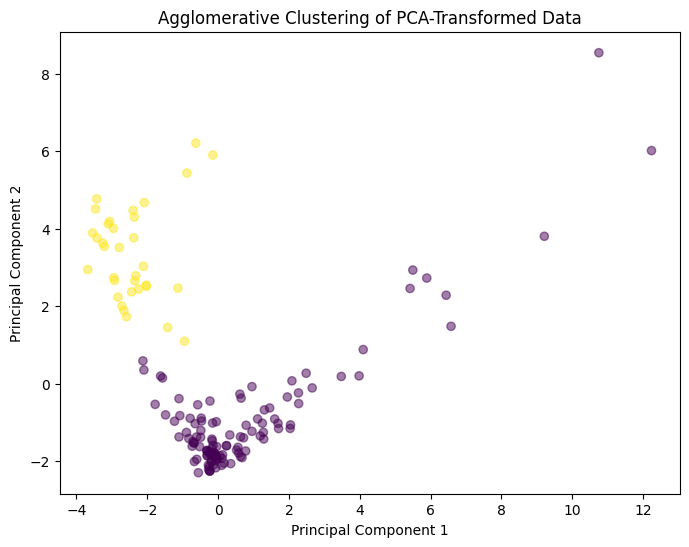

In [28]:
ACS_avg = AgglomerativeClusteringScratch(n_clusters=2, linkage='ward')
y_pred = ACS_avg.fit_predict(X_agg_100_pca)

plt.figure(figsize=(8,6))
plt.scatter(X_agg_100_pca[:,0], X_agg_100_pca[:,1], c=y_pred, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering of PCA-Transformed Data')
plt.show()